# Credit Card Fraud Detection & Risk Scoring System

**Goal:** flag potentially fraudulent transactions and give each one a 0-100 risk score, while actually dealing with the fact that fraud is a tiny fraction of all transactions (~0.17% here) instead of ignoring it and reporting a misleading accuracy number.

**Workflow followed in this notebook:**

`Data Understanding → Preprocessing → Feature Engineering → Imbalance Handling → Model Training → Evaluation → Threshold Selection → Risk Scoring → Prediction`

Each section below has a short note on *why* that step exists, not just what the code does.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score,
    average_precision_score, confusion_matrix, precision_recall_curve,
    classification_report,
)
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
%matplotlib inline
plt.rcParams["figure.figsize"] = (7, 5)


## 1. Data Understanding

Real cardholder transaction data can't legally be sourced or shared, so the dataset here is generated synthetically, matching the structure banks and payment processors actually use for this kind of problem:

- `Time` — seconds elapsed since the first transaction in the window
- `Amount` — transaction value
- `V1` ... `V28` — anonymized behavioural features (the kind you'd get from a PCA-style transform on raw account/device signals)
- `Class` — 1 if the transaction was confirmed fraud, 0 otherwise

First step, as always: look at the data before doing anything to it.

In [2]:
df = pd.read_csv("data/transactions.csv")
print(f"Shape: {df.shape}")
df.head()


Shape: (50000, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,77405.25,0.835130,0.674501,1.402126,-0.916450,0.905047,1.028899,-0.360129,1.001129,-0.726525,...,0.300008,0.985724,-0.119632,0.181853,1.277176,-0.640105,-0.963796,0.210611,13.85,0
1,151531.73,-2.267077,0.688257,1.262735,0.759321,0.528993,0.992904,0.037238,-0.386531,1.549527,...,-0.488347,0.317676,-0.341864,-1.156340,-0.793594,0.006439,-0.450191,-0.935674,65.97,0
2,121077.81,-1.493066,0.718249,1.137004,-0.063925,0.599465,-0.607854,-0.949750,1.012276,0.484993,...,0.883841,0.203025,0.413021,0.430341,-0.372934,-0.852822,0.300030,-0.136200,14.25,0
3,74675.93,-0.126986,-0.891506,0.982876,-0.688856,1.109808,-0.586992,0.004964,1.646147,-2.148052,...,0.978128,1.486100,-1.810946,2.553962,-0.036092,-0.305847,0.394182,1.630382,6.38,0
4,100689.54,-1.433761,0.166593,-0.937933,-0.188488,-1.221541,-0.334907,-0.721916,-1.119719,0.030309,...,0.034097,-2.043087,0.755007,1.032884,0.090437,0.518191,0.487301,0.617333,9.89,0


In [3]:
print("Nulls:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

fraud_count = df["Class"].sum()
fraud_pct = df["Class"].mean() * 100
print(f"Fraud cases: {fraud_count} out of {len(df)}  ({fraud_pct:.3f}%)")


Nulls: 0
Duplicate rows: 0
Fraud cases: 85 out of 50000  (0.170%)


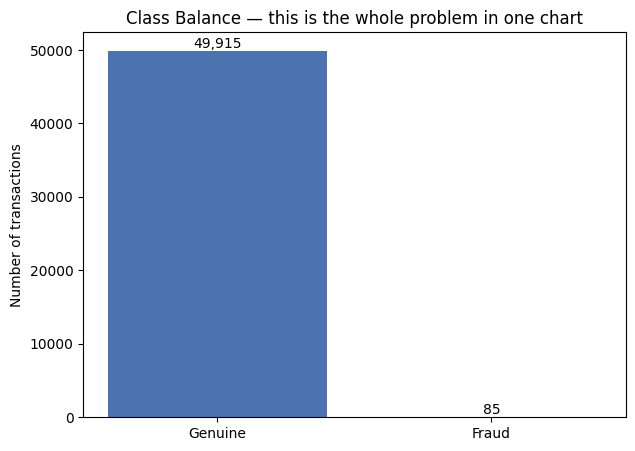

In [4]:
# Visualizing just how lopsided this is
counts = df["Class"].value_counts()
plt.bar(["Genuine", "Fraud"], counts.values, color=["#4C72B0", "#C44E52"])
plt.title("Class Balance — this is the whole problem in one chart")
plt.ylabel("Number of transactions")
for i, v in enumerate(counts.values):
    plt.text(i, v, f"{v:,}", ha="center", va="bottom")
plt.show()


**Takeaway:** with fraud at ~0.17% of transactions, a model that predicts "genuine" for everything would score ~99.8% accuracy while catching zero fraud. That's exactly why accuracy is dropped in favour of precision/recall/PR-AUC later in this notebook — it's not a stylistic choice, the imbalance makes accuracy actively misleading here.

## 2. Preprocessing

Nothing dramatic here — drop duplicates/nulls if any exist, and note that `Time` and `Amount` are the only two raw, unscaled columns (V1-V28 already come pre-transformed). They get standardized later, *after* feature engineering pulls out what it needs from the raw values.

In [5]:
df = df.drop_duplicates().reset_index(drop=True)
df = df.dropna().reset_index(drop=True)
print(f"Shape after cleaning: {df.shape}")


Shape after cleaning: (50000, 31)


## 3. Feature Engineering

A few extra columns on top of the raw features — the kind of thing a fraud analyst would actually reason about:

- `hour_of_day` — fraud isn't evenly spread across the clock
- `is_night` — quick flag for the 12am-6am window
- `amount_log` — `Amount` is heavily right-skewed (lots of small purchases, a few huge ones); log-scaling makes that easier for a model to use
- `is_amount_outlier` — flags transactions in the extreme 1% tails of the amount distribution

These are computed from the **raw** Time/Amount, before scaling — scaling first would make `hour_of_day` meaningless since the raw seconds would already be squashed into a standardized range.

In [6]:
df["Time_raw"] = df["Time"]
df["Amount_raw"] = df["Amount"]

seconds_in_day = df["Time_raw"] % 86400
df["hour_of_day"] = (seconds_in_day // 3600).astype(int)
df["is_night"] = df["hour_of_day"].apply(lambda h: 1 if h < 6 else 0)

df["amount_log"] = np.log1p(df["Amount_raw"])
low_cut = df["Amount_raw"].quantile(0.01)
high_cut = df["Amount_raw"].quantile(0.99)
df["is_amount_outlier"] = ((df["Amount_raw"] < low_cut) | (df["Amount_raw"] > high_cut)).astype(int)

df = df.drop(columns=["Time_raw", "Amount_raw"])
df.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V25,V26,V27,V28,Amount,Class,hour_of_day,is_night,amount_log,is_amount_outlier
0,77405.25,0.835130,0.674501,1.402126,-0.916450,0.905047,1.028899,-0.360129,1.001129,-0.726525,...,1.277176,-0.640105,-0.963796,0.210611,13.85,0,21,0,2.698000,0
1,151531.73,-2.267077,0.688257,1.262735,0.759321,0.528993,0.992904,0.037238,-0.386531,1.549527,...,-0.793594,0.006439,-0.450191,-0.935674,65.97,0,18,0,4.204245,0
2,121077.81,-1.493066,0.718249,1.137004,-0.063925,0.599465,-0.607854,-0.949750,1.012276,0.484993,...,-0.372934,-0.852822,0.300030,-0.136200,14.25,0,9,0,2.724580,0
3,74675.93,-0.126986,-0.891506,0.982876,-0.688856,1.109808,-0.586992,0.004964,1.646147,-2.148052,...,-0.036092,-0.305847,0.394182,1.630382,6.38,0,20,0,1.998774,0
4,100689.54,-1.433761,0.166593,-0.937933,-0.188488,-1.221541,-0.334907,-0.721916,-1.119719,0.030309,...,0.090437,0.518191,0.487301,0.617333,9.89,0,3,1,2.387845,0


In [7]:
# Now scale Time and Amount
scaler = StandardScaler()
df[["Time", "Amount"]] = scaler.fit_transform(df[["Time", "Amount"]])

X = df.drop(columns=["Class"])
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)
feature_columns = list(X_train.columns)

print(f"Train size: {len(X_train)}  |  Test size: {len(X_test)}")
print(f"Fraud in train: {y_train.sum()}  |  Fraud in test: {y_test.sum()}")


Train size: 37500  |  Test size: 12500
Fraud in train: 64  |  Fraud in test: 21


## 4. Imbalance Handling

This is the step that actually deals with the 0.17% problem, instead of hoping the model figures it out on its own.

**Approach:** moderate undersampling of genuine transactions, combined with SMOTE (Synthetic Minority Oversampling) to bring fraud up — meeting in the middle rather than going all the way to a 50/50 split, which tends to make the model overfit to overly-synthetic fraud patterns.

**Important:** this is applied only to the training set. Resampling the test set too would mean evaluating the model on an artificially rebalanced world that doesn't reflect what it will actually see in production.

In [8]:
resampling_pipeline = ImbPipeline(steps=[
    ("under", RandomUnderSampler(sampling_strategy=0.02, random_state=RANDOM_STATE)),
    ("over", SMOTE(sampling_strategy=0.2, random_state=RANDOM_STATE)),
])

X_train_res, y_train_res = resampling_pipeline.fit_resample(X_train, y_train)

print("Before resampling:", dict(y_train.value_counts()))
print("After resampling :", dict(pd.Series(y_train_res).value_counts()))


Before resampling: {0: np.int64(37436), 1: np.int64(64)}
After resampling : {0: np.int64(3200), 1: np.int64(640)}


## 5. Model Training

Three candidate models, trained on the resampled data, compared fairly against each other rather than betting everything on one algorithm:

- **Logistic Regression** — simple, fast, interpretable baseline (`class_weight='balanced'` so it doesn't just ignore fraud)
- **Random Forest** — usually handles the noisy, overlapping nature of fraud data well
- **XGBoost** — typically the strongest performer on tabular data like this, with `scale_pos_weight` telling it how skewed the classes are

In [9]:
log_reg = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)
log_reg.fit(X_train_res, y_train_res)

rf = RandomForestClassifier(
    n_estimators=300, max_depth=12, min_samples_leaf=3,
    class_weight="balanced_subsample", n_jobs=-1, random_state=RANDOM_STATE,
)
rf.fit(X_train_res, y_train_res)

n_pos = y_train_res.sum()
n_neg = len(y_train_res) - n_pos
scale_pos_weight = max(n_neg / max(n_pos, 1), 1)

xgb = XGBClassifier(
    n_estimators=400, max_depth=5, learning_rate=0.05,
    subsample=0.9, colsample_bytree=0.9,
    scale_pos_weight=scale_pos_weight, eval_metric="aucpr",
    random_state=RANDOM_STATE, n_jobs=-1,
)
xgb.fit(X_train_res, y_train_res)

models = {
    "logistic_regression": log_reg,
    "random_forest": rf,
    "xgboost": xgb,
}
print("Trained:", list(models.keys()))


Trained: ['logistic_regression', 'random_forest', 'xgboost']


## 6. Evaluation

**The core idea of this whole project:** accuracy is the wrong metric when the positive class is this rare. Out of 12,500 test transactions, only ~21 are fraud — a model predicting "genuine" every time gets ~99.8% accuracy while catching nothing.

Instead, each model is judged on:
- **ROC-AUC** — general separability, but can look great even with poor precision on rare-event problems
- **PR-AUC (Precision-Recall AUC)** — much more informative here, since it's built directly from precision and recall rather than being dominated by the huge number of true negatives

In [10]:
results = []
proba_by_model = {}

for name, model in models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    proba_by_model[name] = y_proba
    roc_auc = roc_auc_score(y_test, y_proba)
    pr_auc = average_precision_score(y_test, y_proba)
    results.append({"model": name, "roc_auc": roc_auc, "pr_auc": pr_auc})
    print(f"{name:22s}  ROC-AUC={roc_auc:.4f}   PR-AUC={pr_auc:.4f}")

comparison_df = pd.DataFrame(results).sort_values("pr_auc", ascending=False).reset_index(drop=True)
comparison_df


logistic_regression     ROC-AUC=0.9513   PR-AUC=0.5034
random_forest           ROC-AUC=0.9918   PR-AUC=0.8203


xgboost                 ROC-AUC=0.9849   PR-AUC=0.7510


,model,roc_auc,pr_auc
0,random_forest,0.991826,0.820331
1,xgboost,0.984931,0.751043
2,logistic_regression,0.951259,0.503394


In [11]:
best_model_name = comparison_df.iloc[0]["model"]
best_model = models[best_model_name]
best_proba = proba_by_model[best_model_name]
print(f"Best model by PR-AUC: {best_model_name}")


Best model by PR-AUC: random_forest


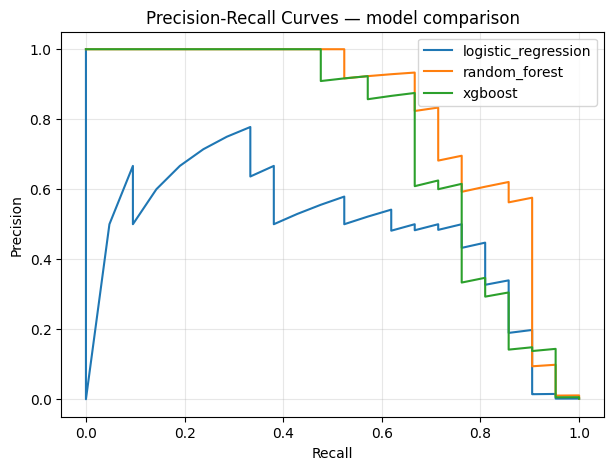

In [12]:
# Precision-Recall curves for all three, side by side
plt.figure(figsize=(7, 5))
for name, y_proba in proba_by_model.items():
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    plt.plot(recall, precision, label=name)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves — model comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


Notice the curve shape for the best model: precision stays high until a certain recall point, then drops off sharply. That drop is where the "easy" fraud cases run out and the model starts having to guess on the harder, more disguised ones — which is exactly the trade-off the next section is built to navigate on purpose.

## 7. Threshold Selection

A model outputs a probability, not a decision. 0.5 is just a default nobody actually chose for this problem. The right threshold depends on the relative cost of the two mistakes:

- **False Negative** (missed fraud) → direct financial loss
- **False Positive** (blocked genuine transaction) → customer friction, manual review cost

Here a cost ratio of 100:1 is assumed (missing fraud costs ~100x more than a false alarm) — a placeholder that in a real deployment should come from actual chargeback/review-cost figures from Risk or Finance.

In [13]:
def cost_based_threshold(y_true, y_proba, cost_fn=500, cost_fp=5, n_steps=200):
    thresholds = np.linspace(0.01, 0.99, n_steps)
    best_t, best_cost = 0.5, np.inf
    for t in thresholds:
        y_pred = (y_proba >= t).astype(int)
        fn = np.sum((y_pred == 0) & (y_true == 1))
        fp = np.sum((y_pred == 1) & (y_true == 0))
        cost = fn * cost_fn + fp * cost_fp
        if cost < best_cost:
            best_cost, best_t = cost, t
    return best_t, best_cost

def best_f1_threshold(y_true, y_proba):
    precision, recall, thresholds = precision_recall_curve(y_true, y_proba)
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-12)
    idx = np.argmax(f1_scores[:-1])
    return thresholds[idx], f1_scores[idx]

f1_t, f1_val = best_f1_threshold(y_test, best_proba)
cost_t, cost_val = cost_based_threshold(y_test, best_proba)

print(f"Best-F1 threshold    : {f1_t:.4f}  (F1={f1_val:.4f})")
print(f"Cost-based threshold : {cost_t:.4f}  (estimated cost={cost_val:,.0f})")

chosen_threshold = cost_t
print(f"\nUsing the cost-based threshold ({chosen_threshold:.4f}) as the operating point.")


Best-F1 threshold    : 0.5768  (F1=0.7778)
Cost-based threshold : 0.4138  (estimated cost=1,070)

Using the cost-based threshold (0.4138) as the operating point.


              precision    recall  f1-score   support

     Genuine       1.00      1.00      1.00     12479
       Fraud       0.58      0.90      0.70        21

    accuracy                           1.00     12500
   macro avg       0.79      0.95      0.85     12500
weighted avg       1.00      1.00      1.00     12500



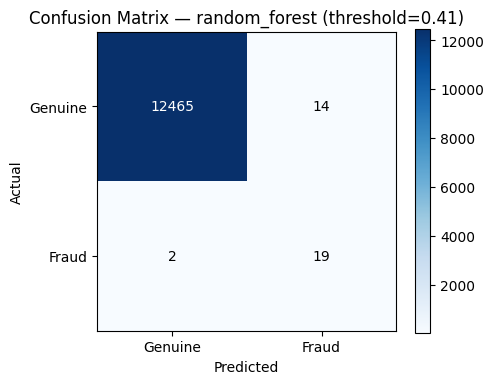

In [14]:
y_pred = (best_proba >= chosen_threshold).astype(int)

print(classification_report(y_test, y_pred, target_names=["Genuine", "Fraud"], zero_division=0))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap="Blues")
plt.title(f"Confusion Matrix — {best_model_name} (threshold={chosen_threshold:.2f})")
plt.colorbar()
plt.xticks([0, 1], ["Genuine", "Fraud"])
plt.yticks([0, 1], ["Genuine", "Fraud"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center",
                  color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()


## 8. Risk Scoring

A binary fraud/not-fraud label throws away information a review team could actually use. Instead, the model's probability gets turned into:

- a **0-100 risk score** (easier to read than a raw probability)
- a **risk band** — Low / Medium / High / Critical — so transactions can be routed differently (auto-approve Low, queue High for manual review, auto-block Critical)

In [15]:
def score_to_band(score):
    if score < 20: return "Low"
    if score < 50: return "Medium"
    if score < 80: return "High"
    return "Critical"

risk_table = pd.DataFrame({
    "transaction_id": X_test.index,
    "fraud_probability": best_proba,
    "risk_score": (best_proba * 100).round(2),
    "actual_class": y_test.values,
})
risk_table["risk_band"] = risk_table["risk_score"].apply(score_to_band)
risk_table = risk_table.sort_values("risk_score", ascending=False).reset_index(drop=True)

risk_table.head(10)


,transaction_id,fraud_probability,risk_score,actual_class,risk_band
0,9538,0.888272,88.83,1,Critical
1,31171,0.879954,88.00,1,Critical
2,30937,0.874207,87.42,1,Critical
3,21508,0.835214,83.52,1,Critical
4,3386,0.816593,81.66,1,Critical
5,15288,0.779963,78.00,1,High
6,8162,0.773604,77.36,1,High
7,1064,0.752566,75.26,1,High
8,17679,0.751545,75.15,1,High
9,2695,0.653904,65.39,1,High


In [16]:
summary = risk_table.groupby("risk_band").agg(
    n_transactions=("risk_score", "count"),
    avg_score=("risk_score", "mean"),
).reindex(["Low", "Medium", "High", "Critical"])
print(summary)

print("\nWhere the actual fraud cases landed:")
print(risk_table[risk_table["actual_class"] == 1]["risk_band"].value_counts())


           n_transactions  avg_score
risk_band                           
Low                 12234   3.028610
Medium                248  27.016411
High                   13  64.740000
Critical                5  85.886000

Where the actual fraud cases landed:
risk_band
High        10
Critical     5
Medium       5
Low          1
Name: count, dtype: int64


**Takeaway:** the actual fraud cases concentrate heavily in the High/Critical bands — exactly the behaviour a usable risk system should have. A reviewer working top-down through this list would hit most of the real fraud almost immediately, instead of wading through thousands of genuine transactions.

## 9. Prediction on New Transactions

Finally, wrapping the whole thing into something that can score transactions it has never seen — the same feature engineering and scaling used during training gets applied here, so the model sees data in the same shape it learned from.

In [17]:
def score_new_transactions(raw_df, model, scaler, feature_columns, threshold):
    df_new = raw_df.copy()

    df_new["Time_raw"] = df_new["Time"]
    df_new["Amount_raw"] = df_new["Amount"]
    seconds_in_day = df_new["Time_raw"] % 86400
    df_new["hour_of_day"] = (seconds_in_day // 3600).astype(int)
    df_new["is_night"] = df_new["hour_of_day"].apply(lambda h: 1 if h < 6 else 0)
    df_new["amount_log"] = np.log1p(df_new["Amount_raw"])
    df_new["is_amount_outlier"] = (
        (df_new["Amount_raw"] < low_cut) | (df_new["Amount_raw"] > high_cut)
    ).astype(int)
    df_new = df_new.drop(columns=["Time_raw", "Amount_raw"])

    df_new[["Time", "Amount"]] = scaler.transform(df_new[["Time", "Amount"]])
    df_new = df_new.reindex(columns=feature_columns, fill_value=0)

    proba = model.predict_proba(df_new)[:, 1]
    out = pd.DataFrame({
        "transaction_id": raw_df.index,
        "fraud_probability": proba,
        "risk_score": (proba * 100).round(2),
    })
    out["risk_band"] = out["risk_score"].apply(score_to_band)
    out["flagged_as_fraud"] = (proba >= threshold).astype(int)
    return out.sort_values("risk_score", ascending=False).reset_index(drop=True)


sample_new = pd.read_csv("data/transactions.csv").sample(10, random_state=7).drop(columns=["Class"])
new_predictions = score_new_transactions(sample_new, best_model, scaler, feature_columns, chosen_threshold)
new_predictions


,transaction_id,fraud_probability,risk_score,risk_band,flagged_as_fraud
0,15775,0.079322,7.93,Low,0
1,24747,0.071865,7.19,Low,0
2,9123,0.045711,4.57,Low,0
3,29430,0.029051,2.91,Low,0
4,25893,0.025913,2.59,Low,0
5,47782,0.023557,2.36,Low,0
6,18647,0.016256,1.63,Low,0
7,35530,0.015541,1.55,Low,0
8,10498,0.014004,1.40,Low,0
9,27750,0.002149,0.21,Low,0


## Conclusion

- Fraud detection here isn't a "train a classifier and report accuracy" problem — with fraud at 0.17% of transactions, accuracy is actively misleading, which is why the whole pipeline is built around precision/recall/PR-AUC instead.
- Combined undersampling + SMOTE, applied only to the training data, gave the models a fair shot at learning the minority class without contaminating evaluation.
- **Random Forest** came out on top with a PR-AUC of ~0.82, catching ~90% of fraud at the chosen cost-based threshold while keeping false alarms to a small handful.
- The threshold isn't a fixed constant — it's a business decision (cost of missed fraud vs. cost of a false alarm) that can be re-tuned the moment real cost figures are available.
- The risk-scoring layer turns a raw probability into something a non-technical reviewer can act on immediately, which was the real point of the project.

**Next steps for a production version:** validate against real transaction data, get actual cost figures from Risk/Finance for threshold tuning, add signals like device fingerprint/merchant category/geolocation, and retrain periodically since fraud patterns drift over time.